In [81]:
from google.colab import drive
drive.mount('/content/drive')

# 데이터는 한이음 - 데이터- '부동산'탭에 다 저장해놓음 (각자 다운받아서 데이터 로드, 전처리는 코드 그대로 진행하면 됨)
# datetime으로 데이터 타입 바꾸고 병합 해야됨
# https://brique-analytics.tistory.com/23 - 참고 시 Good

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 13 not upgraded.
Need to get 9,599 kB of archives.
After this operation, 29.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu focal/universe amd64 fonts-nanum all 20180306-3 [9,599 kB]
Fetched 9,599 kB in 1min 28s (110 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 76, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 123069 files an

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

In [ ]:
#@title 매매가격지수 (예측값)


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/한이음/아파트 매매가격지수.xlsx')
df.head()

,구분,전국,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 177,Unnamed: 178,Unnamed: 179,Unnamed: 180,Unnamed: 181,Unnamed: 182,Unnamed: 183,Unnamed: 184,Unnamed: 185,기타지방
0,구분,전국,서울특별시,강북\n14개구,강북구,광진구,노원구,도봉구,동대문구,마포구,...,의창구,진해구,양산,거제,진주시,김해시,통영시,제주/\n서귀포,서귀포,기타지방
1,Classification,Total,Seoul,Northern seoul,Gangbuk-gu,Gwangjin-gu,Nowon-gu,Dobong-gu,Dongdaemun-gu,Mapo-gu,...,Uichang,Jinhae,Yangsan,Geoje,Jinju,Kimhae,Tongyoung,Jeju-do,Jeju/\nSeogwipo,Non-Metropolitan Area
2,86.1,15.910037,12.634687,17.654568,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,15.910037,12.656584,17.625626,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3,15.880737,12.634687,17.596684,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.tail(10)

,구분,전국,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 177,Unnamed: 178,Unnamed: 179,Unnamed: 180,Unnamed: 181,Unnamed: 182,Unnamed: 183,Unnamed: 184,Unnamed: 185,기타지방
440,7,100.677875,100.638135,100.325551,100.59932,101.506611,99.837671,100.405956,99.895895,100.691852,...,101.601288,103.70509,103.457564,101.565087,104.504346,99.902074,101.556082,NaN,105.104997,102.271545
441,8,100.449869,100.491861,100.134176,100.559954,101.574239,99.481922,99.784904,99.843461,100.598912,...,101.689343,103.83718,103.309848,101.604196,104.566137,99.656796,101.578963,NaN,105.170226,102.29218
442,9,100.209062,100.297206,99.909059,100.535799,101.327103,99.049681,99.161915,99.635978,100.585191,...,101.72653,103.934294,103.042125,101.539048,104.50702,99.3766,101.618849,NaN,105.253394,102.225038
443,10,99.468871,99.626927,99.109509,99.841839,100.969524,97.659531,97.285861,98.748021,100.312566,...,101.402861,104.062988,102.748275,101.453795,104.233654,98.965617,101.593121,NaN,105.159935,101.908926
444,11,98.057422,98.21648,97.612834,98.534844,100.293123,95.53742,95.450658,96.496211,99.016508,...,100.738709,103.831967,101.541668,100.679178,103.882573,98.201458,101.470657,NaN,105.138961,101.268345
445,12,96.569873,96.809521,96.316564,96.974,99.657297,94.162228,93.547533,94.961852,97.603674,...,99.166092,103.556859,100.710065,100.262769,102.568492,97.232509,101.421831,NaN,104.559209,100.48229
446,2023.1,94.724287,94.784047,94.292981,95.412982,98.06978,91.814036,91.095139,92.722167,95.999441,...,97.3665,102.682118,99.934588,99.299369,101.411414,96.414977,101.306368,NaN,103.351051,99.386142
447,2,93.626154,93.649544,93.03027,92.775837,97.00874,90.326958,90.217578,91.325014,94.918085,...,96.626062,102.484765,99.562863,97.727557,101.039402,95.631231,101.215586,NaN,102.835837,98.719167
448,3,92.481888,92.552918,91.692069,91.62605,95.311763,88.441094,89.296747,90.326496,93.823778,...,96.337728,102.32544,98.60047,96.693323,100.636321,94.810368,101.094125,NaN,101.436986,98.109366
449,4,91.424186,91.655686,90.723878,90.663332,94.574089,87.540849,88.308249,89.22219,92.722874,...,96.278157,101.659032,97.60489,95.093601,100.035899,93.599557,100.929872,NaN,100.860974,97.505836


In [ ]:
# 전국의 매매가격지수와 해당하는 기간만 지정해 전처리

price = df.iloc[list(range(422, 449)), [0, 1]]
price

,구분,전국
422,2021.1,84.20777
423,2,85.687847
424,3,87.170534
425,4,88.417382
426,5,89.526341
427,6,91.217765
428,7,92.603555
429,8,94.440802
430,9,96.299362
431,10,97.56289


In [ ]:
price.loc[422, '구분'] = '2021-1'
price.head()

,구분,전국
422,2021-1,84.20777
423,2,85.687847
424,3,87.170534
425,4,88.417382
426,5,89.526341


In [ ]:
price['구분'] = ['2021-1', '2021-2', '2021-3', '2021-4', '2021-5', '2021-6', '2021-7', '2021-8', '2021-9', '2021-10', '2021-11', '2021-12',
                 '2022-1', '2022-2', '2022-3', '2022-4', '2022-5', '2022-6', '2022-7', '2022-8', '2022-9', '2022-10', '2022-11', '2022-12',
                 '2023-1', '2023-2', '2023-3']
price

,구분,전국
422,2021-1,84.20777
423,2021-2,85.687847
424,2021-3,87.170534
425,2021-4,88.417382
426,2021-5,89.526341
427,2021-6,91.217765
428,2021-7,92.603555
429,2021-8,94.440802
430,2021-9,96.299362
431,2021-10,97.56289


In [ ]:
price.columns = ['시점', '매매가격지수']
price['시점'] = pd.to_datetime(price['시점'], format='%Y-%m')
price.head()

,시점,매매가격지수
422,2021-01-01,84.20777
423,2021-02-01,85.687847
424,2021-03-01,87.170534
425,2021-04-01,88.417382
426,2021-05-01,89.526341


In [ ]:
price.dtypes

시점        datetime64[ns]
매매가격지수            object
dtype: object

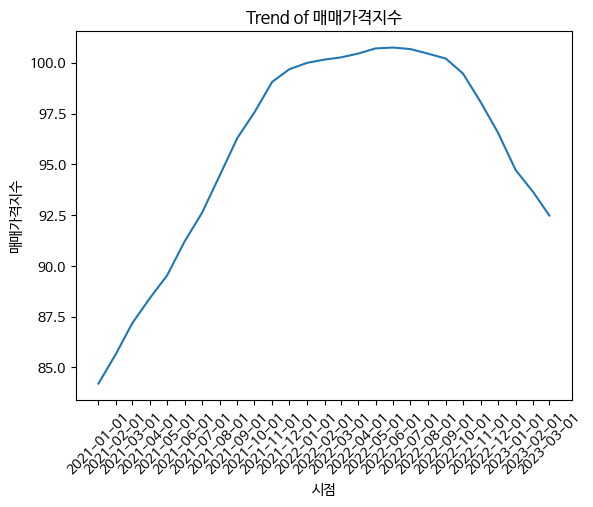

In [ ]:
plt.plot(price['시점'], price['매매가격지수'])
plt.title('Trend of 매매가격지수')
plt.xlabel('시점')
plt.ylabel('매매가격지수')
plt.xticks(rotation=45)
plt.xticks(price['시점'], rotation=45)
plt.show()
# 우상향하는 추세로 보임

In [ ]:
#@title 1. 금리 (한국은행)


In [ ]:
service_key = "21SC44F70ZNCSG2AMIWU" # api 인증키
search_s = '20210101' # 기준금리 조회 시작 날짜
search_e = '20230331' # 기준금리 조회 종료 날짜

In [ ]:
!pip install PublicDataReader

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.8 MB/s eta 0:00:00


In [ ]:
from PublicDataReader import Ecos

api = Ecos(service_key)

base_rate = api.get_statistic_search(통계표코드="722Y001", 주기="D", 검색시작일자=search_s, 검색종료일자=search_e)
base_rate = base_rate[base_rate['통계항목명1'] == '한국은행 기준금리'][['시점', '값']]

In [ ]:
base_rate['시점'] = pd.to_datetime(base_rate['시점'])
base_rate['값'] = base_rate['값'].astype(float)
base_rate.set_index('시점', inplace=True)
base_rate.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 820 entries, 2021-01-01 to 2023-03-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   값       820 non-null    float64
dtypes: float64(1)
memory usage: 12.8 KB


In [ ]:
base_rate.head

<bound method NDFrame.head of               값
시점             
2021-01-01  0.5
2021-01-02  0.5
2021-01-03  0.5
2021-01-04  0.5
2021-01-05  0.5
...         ...
2023-03-27  3.5
2023-03-28  3.5
2023-03-29  3.5
2023-03-30  3.5
2023-03-31  3.5

[820 rows x 1 columns]>

<Axes: title={'center': 'Base Rate'}, xlabel='시점'>

/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL 

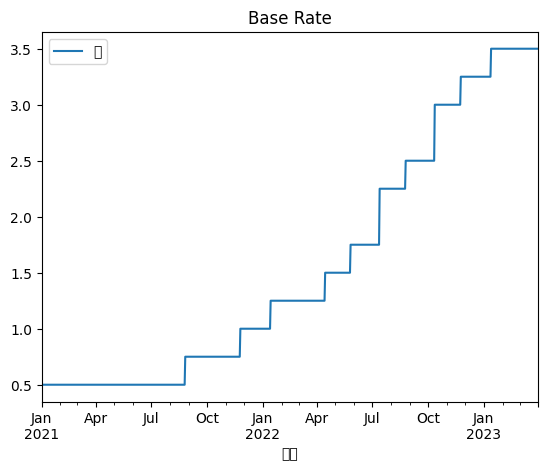

In [ ]:
base_rate.plot(title='Base Rate')

In [ ]:
base_rate

,값
시점,
2021-01-01,0.5
2021-01-02,0.5
2021-01-03,0.5
2021-01-04,0.5
2021-01-05,0.5
...,...
2023-03-27,3.5
2023-03-28,3.5
2023-03-29,3.5


In [ ]:
# 금리의 경우 매일매일의 값이 존재하기 때문에 월 단위로 바꾸는 전처리

rate = base_rate.resample('MS').first()

rate.head()

,값
시점,
2021-01-01,0.5
2021-02-01,0.5
2021-03-01,0.5
2021-04-01,0.5
2021-05-01,0.5


In [ ]:
rate.index = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20',
                '21', '22', '23', '24', '25', '26']
rate['시점'] = ['2021-1', '2021-2', '2021-3', '2021-4', '2021-5', '2021-6', '2021-7', '2021-8', '2021-9', '2021-10', '2021-11', '2021-12',
                 '2022-1', '2022-2', '2022-3', '2022-4', '2022-5', '2022-6', '2022-7', '2022-8', '2022-9', '2022-10', '2022-11', '2022-12',
                 '2023-1', '2023-2', '2023-3']
rate.head()

,값,시점
0,0.5,2021-1
1,0.5,2021-2
2,0.5,2021-3
3,0.5,2021-4
4,0.5,2021-5


In [ ]:
rate.columns = ['금리', '시점']
rate['시점'] = pd.to_datetime(rate['시점'], format='%Y-%m')
rate.head()

,금리,시점
0,0.5,2021-01-01
1,0.5,2021-02-01
2,0.5,2021-03-01
3,0.5,2021-04-01
4,0.5,2021-05-01


In [ ]:
rate.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   금리      27 non-null     float64       
 1   시점      27 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 648.0+ bytes


In [ ]:
#@title 환율

In [ ]:
import yfinance as yf
from datetime import datetime

enddate=datetime.now().strftime('%Y-%m-%d')
kospi=yf.download('^KS11', '2021-01-01', '2023-03-31', auto_adjust=True)
kospi

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Volume
Date,,,,,
2021-01-04,2874.500000,2946.540039,2869.110107,2944.449951,1026500
2021-01-05,2943.669922,2990.570068,2921.840088,2990.570068,1519900
2021-01-06,2993.340088,3027.159912,2961.370117,2968.209961,1793400
2021-01-07,2980.750000,3055.280029,2980.750000,3031.679932,1524700
2021-01-08,3040.110107,3161.110107,3040.110107,3152.179932,1297900
...,...,...,...,...,...
2023-03-24,2421.270020,2423.760010,2399.489990,2414.959961,470100
2023-03-27,2423.939941,2423.939941,2395.969971,2409.219971,472200
2023-03-28,2418.689941,2434.939941,2415.340088,2434.939941,523500


In [ ]:
#@title 2. GDP


In [67]:
gdp = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/한이음/국내총생산에 대한 지출_1.csv')
gdp

,통계표,계정항목,단위,변환,2019/Q1,2019/Q2,2019/Q3,2019/Q4,2020/Q1,2020/Q2,...,2021/Q2,2021/Q3,2021/Q4,2022/Q1,2022/Q2,2022/Q3,2022/Q4,2023/Q1,2023/Q2,2023/Q3
0,"2.1.2.2.3. 국내총생산에 대한 지출(원계열, 명목, 분기 및 연간)",최종소비지출,십억원,원자료,"312,229.6","311,487.8","315,525.8","325,353.7","311,930.6","309,842",...,"331,221.8","333,771.7","346,677.8","348,387.4","357,765.8","364,668.8","374,280.4","378,653.6",NaN,NaN
1,"2.1.2.2.3. 국내총생산에 대한 지출(원계열, 명목, 분기 및 연간)",민간,십억원,원자료,"230,621.3","228,204.8","235,278.2","241,829.5","222,805.4","220,390.9",...,"234,846.9","241,474.9","250,762.4","246,251.9","254,587.4","266,904.1","271,654.4","268,813.5",NaN,NaN
2,"2.1.2.2.3. 국내총생산에 대한 지출(원계열, 명목, 분기 및 연간)",가계,십억원,원자료,"221,667.3","219,742.7","226,253.5","233,572.9","214,124.5","212,658.5",...,"226,733.2","232,903.6","242,867.4","236,903.9","245,931.7","257,766.1","263,372.8","258,887.3",NaN,NaN
3,"2.1.2.2.3. 국내총생산에 대한 지출(원계열, 명목, 분기 및 연간)",가계에 봉사하는 비영리단체,십억원,원자료,"8,954","8,462.1","9,024.8","8,256.6","8,680.9","7,732.4",...,"8,113.7","8,571.4","7,895","9,348","8,655.7","9,138","8,281.5","9,926.1",NaN,NaN
4,"2.1.2.2.3. 국내총생산에 대한 지출(원계열, 명목, 분기 및 연간)",정부,십억원,원자료,"81,608.4","83,283","80,247.6","83,524.2","89,125.2","89,451.1",...,"96,374.8","92,296.8","95,915.3","102,135.5","103,178.4","97,764.7","102,626","109,840.1",NaN,NaN
5,"2.1.2.2.3. 국내총생산에 대한 지출(원계열, 명목, 분기 및 연간)",총자본형성,십억원,원자료,"133,245.7","156,439.5","157,986.9","158,447.4","137,609.3","158,262.6",...,"168,168","176,063.3","184,425.3","152,159.4","176,185.2","195,531.8","193,429.5","166,439.7",NaN,NaN
6,"2.1.2.2.3. 국내총생산에 대한 지출(원계열, 명목, 분기 및 연간)",총고정자본형성,십억원,원자료,"124,971.9","152,187.1","143,288.8","158,554.4","133,930.6","158,215.1",...,"171,523","162,912.6","180,924.8","148,726.6","178,226.2","175,650.3","192,825.3","159,071.3",NaN,NaN
7,"2.1.2.2.3. 국내총생산에 대한 지출(원계열, 명목, 분기 및 연간)",총고정자본형성(민간),십억원,원자료,"109,114.3","120,289.8","125,465","126,160.9","111,995.3","125,524",...,"140,169.2","145,729.6","147,242.6","128,671.7","147,093.1","157,596.8","156,093.7","137,290.8",NaN,NaN
8,"2.1.2.2.3. 국내총생산에 대한 지출(원계열, 명목, 분기 및 연간)",총고정자본형성(정부),십억원,원자료,"15,857.5","31,897.3","17,823.8","32,393.5","21,935.3","32,691.2",...,"31,353.8","17,183.1","33,682.3","20,055","31,133.2","18,053.4","36,731.6","21,780.5",NaN,NaN
9,"2.1.2.2.3. 국내총생산에 대한 지출(원계열, 명목, 분기 및 연간)",건설투자,십억원,원자료,"57,015.5","78,952","73,606.3","81,774.6","61,500.2","80,738.9",...,"85,860.8","81,132.8","90,516.1","66,091.2","90,006.3","84,793.6","94,190.6","70,563.2",NaN,NaN


In [68]:
gdp = gdp.iloc[[20]]

In [69]:
gdp.reset_index(drop=True, inplace=True)
gdp

,통계표,계정항목,단위,변환,2019/Q1,2019/Q2,2019/Q3,2019/Q4,2020/Q1,2020/Q2,...,2021/Q2,2021/Q3,2021/Q4,2022/Q1,2022/Q2,2022/Q3,2022/Q4,2023/Q1,2023/Q2,2023/Q3
0,"2.1.2.2.3. 국내총생산에 대한 지출(원계열, 명목, 분기 및 연간)",국내총생산에 대한 지출,십억원,원자료,"455,551.1","480,832.1","488,771.2","499,343.6","459,774.2","475,617.4",...,"517,054.3","531,525.5","546,939.7","512,012.9","544,239.8","548,892.5","556,628.7","523,816.2",NaN,NaN


In [70]:
gdp1 = gdp.transpose()
gdp1 = gdp1.iloc[4:-2 , :2]

print(gdp1)

                 0
2019/Q1  455,551.1
2019/Q2  480,832.1
2019/Q3  488,771.2
2019/Q4  499,343.6
2020/Q1  459,774.2
2020/Q2  475,617.4
2020/Q3  496,391.7
2020/Q4    508,943
2021/Q1    484,679
2021/Q2  517,054.3
2021/Q3  531,525.5
2021/Q4  546,939.7
2022/Q1  512,012.9
2022/Q2  544,239.8
2022/Q3  548,892.5
2022/Q4  556,628.7
2023/Q1  523,816.2


In [71]:
gdp1.index = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16']
gdp1['시점'] = ['2019-1',	'2019-4', '2019-7','2019-10','2020-1','2020-4','2020-7','2020-10','2021-1', '2021-4',	'2021-7', '2021-10','2022-1','2022-4','2022-7','2022-10','2023-1']
gdp1

,0,시점
0,"455,551.1",2019-1
1,"480,832.1",2019-4
2,"488,771.2",2019-7
3,"499,343.6",2019-10
4,"459,774.2",2020-1
5,"475,617.4",2020-4
6,"496,391.7",2020-7
7,"508,943",2020-10
8,"484,679",2021-1
9,"517,054.3",2021-4


In [72]:
gdp1.columns = ['국내총생산', '시점']
gdp1

,국내총생산,시점
0,"455,551.1",2019-1
1,"480,832.1",2019-4
2,"488,771.2",2019-7
3,"499,343.6",2019-10
4,"459,774.2",2020-1
5,"475,617.4",2020-4
6,"496,391.7",2020-7
7,"508,943",2020-10
8,"484,679",2021-1
9,"517,054.3",2021-4


In [73]:
gdp1['시점'] = pd.to_datetime(gdp1['시점'], format='%Y-%m')

In [74]:
### 분기별 데이터라서 직접 남은 달의 빈값 채워줘야 됨

gdp1.set_index('시점', inplace=True)

gdp1 = gdp1.resample('M').ffill()

gdp1.reset_index(inplace=True)

gdp1['시점'] = gdp1['시점'].dt.strftime('%Y-%m')

gdp1

,시점,국내총생산
0,2019-01,"455,551.1"
1,2019-02,"455,551.1"
2,2019-03,"455,551.1"
3,2019-04,"480,832.1"
4,2019-05,"480,832.1"
5,2019-06,"480,832.1"
6,2019-07,"488,771.2"
7,2019-08,"488,771.2"
8,2019-09,"488,771.2"
9,2019-10,"499,343.6"


In [75]:
gdp2 = pd.DataFrame({'시점':['2023-2', '2023-3'], '국내총생산':['523,816.2', '523,816.2']})
gdp2

,시점,국내총생산
0,2023-2,"523,816.2"
1,2023-3,"523,816.2"


In [76]:
gdp1 = gdp1.append(gdp2, ignore_index=True)

<ipython-input-76-4c34afdbb13d>:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  gdp1 = gdp1.append(gdp2, ignore_index=True)


In [77]:
gdp1['시점'] = pd.to_datetime(gdp1['시점'], format='%Y-%m')
gdp1.dtypes

시점       datetime64[ns]
국내총생산            object
dtype: object

In [79]:
gdp1

,시점,국내총생산
0,2019-01-01,"455,551.1"
1,2019-02-01,"455,551.1"
2,2019-03-01,"455,551.1"
3,2019-04-01,"480,832.1"
4,2019-05-01,"480,832.1"
5,2019-06-01,"480,832.1"
6,2019-07-01,"488,771.2"
7,2019-08-01,"488,771.2"
8,2019-09-01,"488,771.2"
9,2019-10-01,"499,343.6"


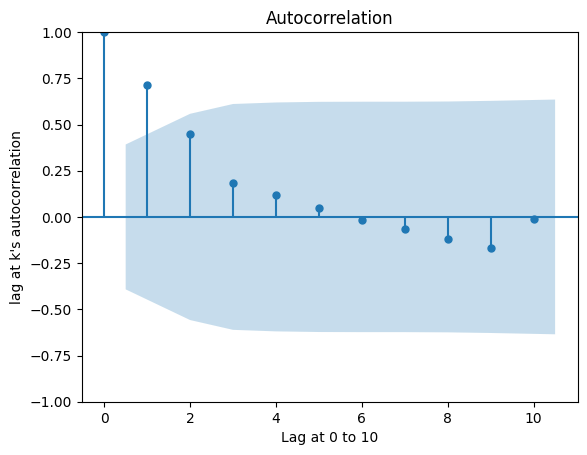

In [ ]:
# ACF 검정 - 비정상적 시계열임을 알 수 있음

def acf_plot(data, N_LAGS, alpha):
    from statsmodels.graphics.tsaplots import plot_acf
    import matplotlib.pyplot as plt

    data = data.str.replace(',', '').astype(float)

    fig = plot_acf(data, lags=N_LAGS, alpha=alpha)
    plt.xlabel(f'Lag at 0 to {N_LAGS}')
    plt.ylabel("lag at k's autocorrelation")
    plt.show()

acf_plot(gdp1['국내총생산'], 10, 0.05)

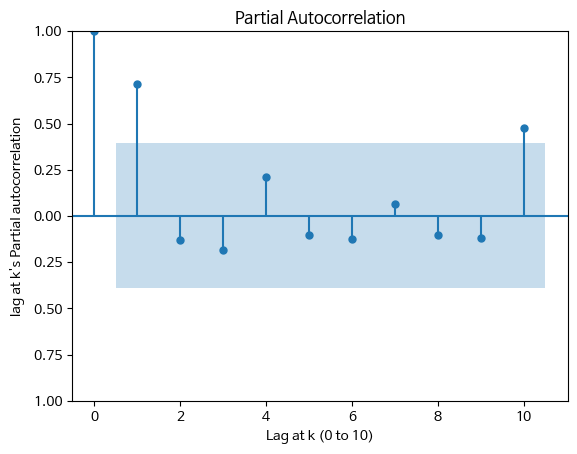

In [ ]:
# PACF 검정 - 시차 1까지 비정상적 시계열임을 알 수 있음

def pacf_plot(data, N_LAGS, pval):
    from statsmodels.graphics.tsaplots import plot_pacf

    data = data.str.replace(',', '').astype(float)

    plot_pacf(data, lags=N_LAGS, alpha=pval, method='ywm')
    plt.xlabel(f'Lag at k (0 to {N_LAGS})')
    plt.ylabel("lag at k's Partial autocorrelation")
    plt.show()

pacf_plot(gdp1['국내총생산'], 10, 0.05)

In [ ]:
#@title 3. 대출금리


In [ ]:
loan = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/한이음/예금은행 대출금리.csv')
loan.head()

,통계표,계정항목,단위,변환,2023/04,2023/03,2023/02,2023/01,2022/12,2022/11,...,2021/10,2021/09,2021/08,2021/07,2021/06,2021/05,2021/04,2021/03,2021/02,2021/01
0,1.3.3.2.1. 예금은행 대출금리(신규취급액 기준),주택담보대출,연리%,원자료,4.24,4.4,4.56,4.58,4.63,4.74,...,3.26,3.01,2.88,2.81,2.74,2.69,2.73,2.73,2.66,2.63


In [ ]:
loan1 = loan.transpose()

loan1 = loan1.iloc[5:, :2]
loan1

,0
2023/03,4.4
2023/02,4.56
2023/01,4.58
2022/12,4.63
2022/11,4.74
2022/10,4.82
2022/09,4.79
2022/08,4.35
2022/07,4.16
2022/06,4.04


In [ ]:
loan1.index = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20',
                '21', '22', '23', '24', '25', '26']
loan1['시점'] = ['2023-3',	'2023-2',	'2023-1','2022-12','2022-11','2022-10','2022-9','2022-8','2022-7','2022-6', '2022-5', '2022-4',
                '2022-3',	'2022-2',	'2022-1', '2021-12','2021-11','2021-10','2021-9','2021-8','2021-7','2021-6','2021-5', '2021-4',
                 '2021-3',	'2021-2',	'2021-1']
loan1.head()

,0,시점
0,4.4,2023-3
1,4.56,2023-2
2,4.58,2023-1
3,4.63,2022-12
4,4.74,2022-11


In [ ]:
loan1.columns = ['대출금리', '시점']
loan1['시점'] = pd.to_datetime(loan1['시점'], format='%Y-%m')
loan1.head()

,대출금리,시점
0,4.4,2023-03-01
1,4.56,2023-02-01
2,4.58,2023-01-01
3,4.63,2022-12-01
4,4.74,2022-11-01


In [ ]:
## 2023년부터이므로 역순으로 재구성해야 됨

loan2 = loan1[::-1].reset_index(drop=True)
loan2.head()

,대출금리,시점
0,2.63,2021-01-01
1,2.66,2021-02-01
2,2.73,2021-03-01
3,2.73,2021-04-01
4,2.69,2021-05-01


In [ ]:
loan2.dtypes

대출금리            object
시점      datetime64[ns]
dtype: object

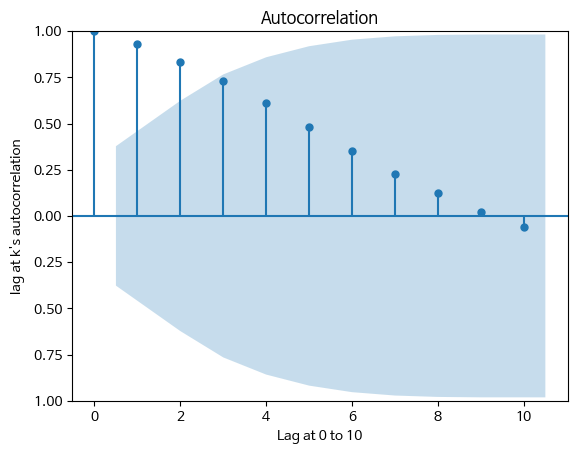

In [ ]:
# ACF 검정 - 비정상적 시계열임을 알 수 있음

def acf_plot(data, N_LAGS, alpha):
    from statsmodels.graphics.tsaplots import plot_acf
    import matplotlib.pyplot as plt

    fig = plot_acf(data, lags=N_LAGS, alpha=alpha)
    plt.xlabel(f'Lag at 0 to {N_LAGS}')
    plt.ylabel("lag at k's autocorrelation")
    plt.show()

acf_plot(loan2['대출금리'], 10, 0.05)

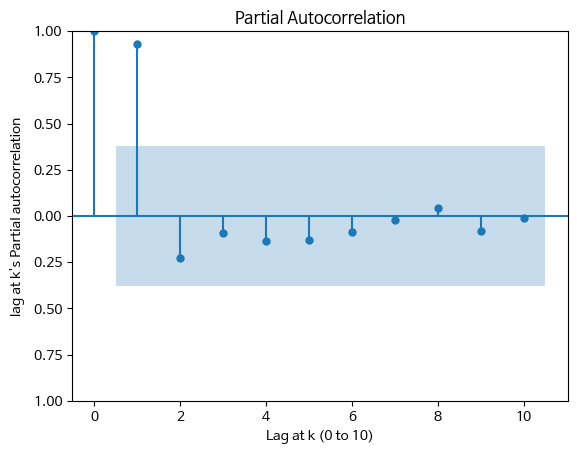

In [ ]:
# PACF 검정 - 시차 1까지 비정상적 시계열임을 알 수 있음

def pacf_plot(data, N_LAGS, pval):
    from statsmodels.graphics.tsaplots import plot_pacf

    plot_pacf(data, lags=N_LAGS, alpha=pval, method='ywm')
    plt.xlabel(f'Lag at k (0 to {N_LAGS})')
    plt.ylabel("lag at k's Partial autocorrelation")
    plt.show()

pacf_plot(loan2['대출금리'], 10, 0.05)

In [ ]:
#@title 4. (아파트) 매매 거래량


In [ ]:
pro = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/한이음/매매 거래량.xlsx')
pro.head()

,지역,통계명,단위,'21.01,'21.02,'21.03,'21.04,'21.05,'21.06,'21.07,...,'22.07,'22.08,'22.09,'22.10,'22.11,'22.12,'23.01,'23.02,'23.03,'23.04
0,전국,아파트거래_월별,동(호)수,"113,272","107,119","105,463","111,192","109,821","105,502","102,785",...,"42,595","51,007","37,727","39,369","38,186","52,385","39,124","63,909","59,750","58,791"


In [ ]:
pro1 = pro.transpose()

pro1 = pro1.iloc[3:-1, :2]
pro1

,0
'21.01,"113,272"
'21.02,"107,119"
'21.03,"105,463"
'21.04,"111,192"
'21.05,"109,821"
'21.06,"105,502"
'21.07,"102,785"
'21.08,"98,278"
'21.09,"89,499"
'21.10,"85,762"


In [ ]:
pro1.index = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20',
                '21', '22', '23', '24', '25', '26']
pro1['시점'] = ['2021-1', '2021-2', '2021-3', '2021-4', '2021-5', '2021-6', '2021-7', '2021-8', '2021-9', '2021-10', '2021-11', '2021-12',
                 '2022-1', '2022-2', '2022-3', '2022-4', '2022-5', '2022-6', '2022-7', '2022-8', '2022-9', '2022-10', '2022-11', '2022-12',
                 '2023-1', '2023-2', '2023-3']
pro1.head()

,0,시점
0,"113,272",2021-1
1,"107,119",2021-2
2,"105,463",2021-3
3,"111,192",2021-4
4,"109,821",2021-5


In [ ]:
pro1.columns = ['매매 거래량', '시점']
pro1['시점'] = pd.to_datetime(pro1['시점'], format='%Y-%m')
pro1.head()

,매매 거래량,시점
0,"113,272",2021-01-01
1,"107,119",2021-02-01
2,"105,463",2021-03-01
3,"111,192",2021-04-01
4,"109,821",2021-05-01


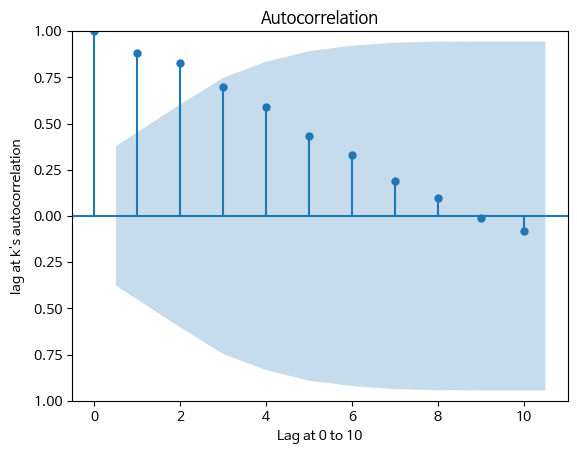

In [ ]:
# ACF 검정 - 비정상적 시계열임을 알 수 있음

def acf_plot(data, N_LAGS, alpha):
    from statsmodels.graphics.tsaplots import plot_acf

    data = data.str.replace(',', '').astype(float)

    fig = plot_acf(data, lags=N_LAGS, alpha=alpha)
    plt.xlabel(f'Lag at 0 to {N_LAGS}')
    plt.ylabel("lag at k's autocorrelation")
    plt.show()

acf_plot(pro1['매매 거래량'], 10, 0.05)

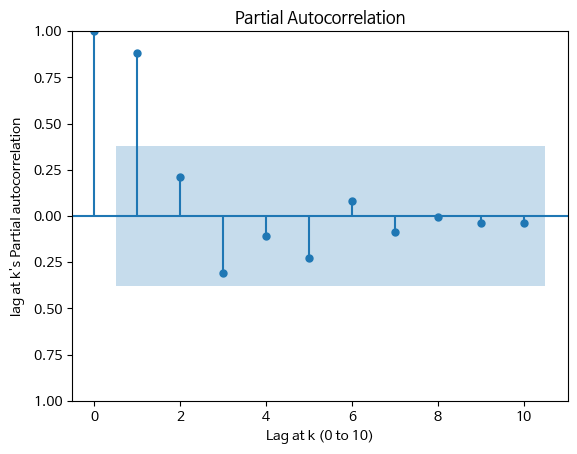

In [ ]:
# PACF 검정 - 시차 1까지 비정상적 시계열임을 알 수 있음


def pacf_plot(data, N_LAGS, pval):
    from statsmodels.graphics.tsaplots import plot_pacf
    data = data.str.replace(',', '').astype(float)

    plot_pacf(data, lags=N_LAGS, alpha=pval, method='ywm')
    plt.xlabel(f'Lag at k (0 to {N_LAGS})')
    plt.ylabel("lag at k's Partial autocorrelation")
    plt.show()

pacf_plot(pro1['매매 거래량'], 10, 0.05)

In [ ]:
#@title 네이버 데이터랩 검색량


In [ ]:
apa_df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/한이음/아파트 (네이버).xlsx')
apa_df.head()

,날짜,아파트
0,2021-01-01,36.95223
1,2021-01-02,41.19621
2,2021-01-03,42.06474
3,2021-01-04,45.20331
4,2021-01-05,42.40031


In [ ]:
# 네이버 데이터랩 '아파트' 키워드량 - 상대적인 수치이므로 백분율로 변환하는 전처리

apa_df['아파트'] = apa_df['아파트'].apply(lambda x: round(float(x), 3) * 0.01)
apa_df.head()

,날짜,아파트
0,2021-01-01,0.36952
1,2021-01-02,0.41196
2,2021-01-03,0.42065
3,2021-01-04,0.45203
4,2021-01-05,0.42400


In [ ]:
#@title 데이터프레임 merge


In [ ]:
# price - 매매가격지수, rate- 금리, gdp1 - 국내총생산, loan2 - 대출금리, pro1 - 매매 거래량
# 환율, 네이버 데이터랩 검색량은 일단 제외하고 진
# '시점'을 공통 열로 해서 데이터프레임 merge하면 됨

In [ ]:
df = pd.merge(price, rate, on='시점')
df = pd.merge(df, gdp1, on='시점')
df = pd.merge(df, loan2, on='시점')
df = pd.merge(df, pro1, on='시점')
df.head()

,시점,매매가격지수,금리,국내총생산,대출금리,매매 거래량
0,2021-01-01,84.20777,0.5,"484,679",2.63,"113,272"
1,2021-02-01,85.687847,0.5,"484,679",2.66,"107,119"
2,2021-03-01,87.170534,0.5,"484,679",2.73,"105,463"
3,2021-04-01,88.417382,0.5,"517,054.3",2.73,"111,192"
4,2021-05-01,89.526341,0.5,"517,054.3",2.69,"109,821"


In [ ]:
df

,시점,매매가격지수,금리,국내총생산,대출금리,매매 거래량
0,2021-01-01,84.20777,0.50,"484,679",2.63,"113,272"
1,2021-02-01,85.687847,0.50,"484,679",2.66,"107,119"
2,2021-03-01,87.170534,0.50,"484,679",2.73,"105,463"
3,2021-04-01,88.417382,0.50,"517,054.3",2.73,"111,192"
4,2021-05-01,89.526341,0.50,"517,054.3",2.69,"109,821"
5,2021-06-01,91.217765,0.50,"517,054.3",2.74,"105,502"
6,2021-07-01,92.603555,0.50,"531,525.5",2.81,"102,785"
7,2021-08-01,94.440802,0.50,"531,525.5",2.88,"98,278"
8,2021-09-01,96.299362,0.75,"531,525.5",3.01,"89,499"
9,2021-10-01,97.56289,0.75,"546,939.7",3.26,"85,762"


In [ ]:
df.dtypes

시점        datetime64[ns]
매매가격지수            object
금리               float64
국내총생산             object
대출금리              object
매매 거래량            object
dtype: object

In [84]:
gdp1.head()

,시점,국내총생산
0,2019-01-01,"455,551.1"
1,2019-02-01,"455,551.1"
2,2019-03-01,"455,551.1"
3,2019-04-01,"480,832.1"
4,2019-05-01,"480,832.1"


In [90]:
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/한이음/시계열1.xlsx')
df.head()

,시점,매매가격지수,금리,국내총생산,대출금리,아파트거래량,아파트 매매거래량
0,2019-01-01,75.859101,1.75,455551,3.12,91868,31305
1,2019-02-01,75.772352,1.75,455551,3.08,78825,28293
2,2019-03-01,75.626463,1.75,455551,3.04,90720,31760
3,2019-04-01,75.443869,1.75,480832,2.98,89977,35893
4,2019-05-01,75.339340,1.75,480832,2.93,82498,35710


In [85]:
df = df.drop(labels='국내총생산', axis=1)
df.head()

,시점,매매가격지수,금리,대출금리,아파트거래량,아파트 매매거래량
0,2019-01-01,75.859101,1.75,3.12,91868,31305
1,2019-02-01,75.772352,1.75,3.08,78825,28293
2,2019-03-01,75.626463,1.75,3.04,90720,31760
3,2019-04-01,75.443869,1.75,2.98,89977,35893
4,2019-05-01,75.339340,1.75,2.93,82498,35710


In [86]:
df = pd.merge(df, gdp1, on='시점')
df.head()

,시점,매매가격지수,금리,대출금리,아파트거래량,아파트 매매거래량,국내총생산
0,2019-01-01,75.859101,1.75,3.12,91868,31305,"455,551.1"
1,2019-02-01,75.772352,1.75,3.08,78825,28293,"455,551.1"
2,2019-03-01,75.626463,1.75,3.04,90720,31760,"455,551.1"
3,2019-04-01,75.443869,1.75,2.98,89977,35893,"480,832.1"
4,2019-05-01,75.339340,1.75,2.93,82498,35710,"480,832.1"


In [87]:
df = df[['시점', '매매가격지수', '금리', '국내총생산', '대출금리', '아파트거래량', '아파트 매매거래량']]
df.head()

,시점,매매가격지수,금리,국내총생산,대출금리,아파트거래량,아파트 매매거래량
0,2019-01-01,75.859101,1.75,"455,551.1",3.12,91868,31305
1,2019-02-01,75.772352,1.75,"455,551.1",3.08,78825,28293
2,2019-03-01,75.626463,1.75,"455,551.1",3.04,90720,31760
3,2019-04-01,75.443869,1.75,"480,832.1",2.98,89977,35893
4,2019-05-01,75.339340,1.75,"480,832.1",2.93,82498,35710


In [89]:
df.to_excel('/content/drive/MyDrive/Colab Notebooks/한이음/시계열_base.xlsx')

In [ ]:
#@title 상관관계 분석

In [ ]:
# 1. 각 시계열의 시차를 고려하지 않고 상관관계 분석

df['매매가격지수'] = pd.to_numeric(df['매매가격지수'], errors='coerce')
df['국내총생산'] = pd.to_numeric(df['국내총생산'], errors='coerce')
df['대출금리'] = pd.to_numeric(df['대출금리'], errors='coerce')
df['매매 거래량'] = pd.to_numeric(df['매매 거래량'], errors='coerce')
df.dtypes

시점        datetime64[ns]
매매가격지수           float64
금리               float64
국내총생산            float64
대출금리             float64
매매 거래량           float64
dtype: object

In [ ]:
correlation = df.corr()
correlation

,매매가격지수,금리,국내총생산,대출금리,매매 거래량
매매가격지수,1.000000,0.495216,NaN,0.747408,NaN
금리,0.495216,1.000000,NaN,0.925242,NaN
국내총생산,NaN,NaN,NaN,NaN,NaN
대출금리,0.747408,0.925242,NaN,1.000000,NaN
매매 거래량,NaN,NaN,NaN,NaN,NaN


In [ ]:
import warnings
warnings.filterwarnings('ignore')

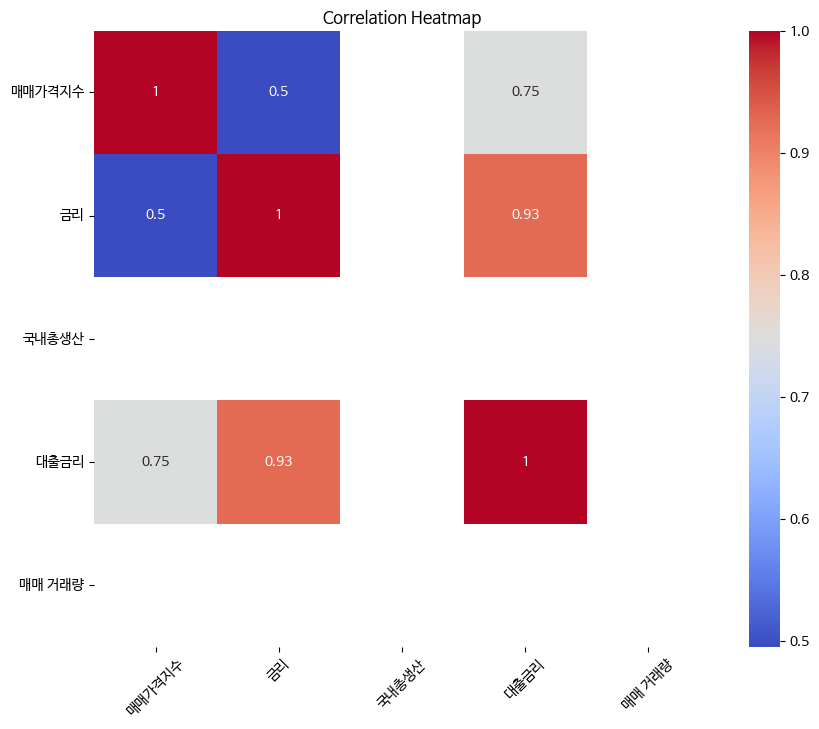

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', square=True)

# Customize the plot
plt.title('Correlation Heatmap')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Display the heatmap
plt.show()

In [ ]:
# 교차상관관계 살펴보기 (두 변수씩 보면 됨)
# 정상성을 만족하도록 만들어야 됨 -> ADF 검정, ACF, PACF 통해 정상성 확인 후 차분여부 결정
# price - 매매가격지수, rate- 금리, gdp1 - 국내총생산, loan1 - 대출금리, pro1 - 매매 거래량

In [ ]:
#@title 정규화 & 모델 적합


In [ ]:
# 정규화- Min-Max Scaler 사용